# TDOA Localization Simulation for a VHF Wildlife Transmitter

This notebook simulates the localization of a VHF wildlife transmitter using Time Difference of Arrival (TDOA). It incorporates realistic measurement errors on the tower positions (GPS error) and the time-of-arrival (clock error).

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.optimize import least_squares, differential_evolution

# Speed of light in m/s (for radio signals)
c = 3e8

## Configuration / Control Variables

We define the simulation parameters. The region is assumed to be a 5 km × 5 km square.

- `n_towers`: Number of towers (recommended: 3+)
- `region_size`: Region size in meters.
- `n_seeds`: Number of random trials for brute-force simulation.
- `gps_error`: Standard deviation of tower position error (meters).
- `time_error`: Standard deviation of time-of-arrival error (seconds).
- `conf_mult`: Confidence multiplier to scale the uncertainty radius (e.g., 3-sigma).

In [24]:
# Simulation parameters
n_towers = 6  # Number of towers
region_size = 5000  # Region: 0 to 5000 m in both x and y
n_seeds = 1000  # Number of trials for brute-force simulation

# Error parameters (realistic values)
gps_error = 5  # Tower GPS error (meters)
time_error = 1e-6  # Time-of-arrival error (seconds)

# Confidence multiplier (e.g., 3-sigma encompasses ~99.7% of the distribution)
conf_mult = 3

# For reproducibility (for baseline simulation only)
np.random.seed(100)

## TDOA Residual Function

The function below computes the residuals between the measured time differences (scaled by the speed of light) and the differences in distances from an estimated transmitter location to each tower (using the first tower as reference).

In [25]:
def tdoa_residuals(est, towers, time_diffs, c):
    """
    Compute residuals for TDOA multilateration.

    Parameters:
      est : array_like
          Estimated transmitter position [x, y].
      towers : array_like
          Array of tower positions (Nx2), with the first tower as reference.
      time_diffs : array_like
          Observed time differences relative to the reference tower.
      c : float
          Speed of signal propagation (m/s).

    Returns:
      residuals : list
          Residuals between the computed distance differences and the time differences scaled by c.
    """
    x, y = est
    ref = towers[0]
    d_ref = np.sqrt((x - ref[0]) ** 2 + (y - ref[1]) ** 2)
    residuals = []
    for i in range(1, len(towers)):
        tower = towers[i]
        d = np.sqrt((x - tower[0]) ** 2 + (y - tower[1]) ** 2)
        residuals.append((d - d_ref) - c * time_diffs[i])
    return residuals

## Nominal TDOA Solution (Error-Free Measurements)

First, we compute the "ideal" (nominal) TDOA solution using error‑free measurements. That is, we compute the time-of-arrival at each tower (without adding noise) based on the true transmitter location and the true tower locations.

The nominal solution is used as a baseline to understand the effect of geometry and for subsequent error propagation.

In [26]:
# Generate a baseline random transmitter and tower configuration (for the baseline case)
true_tx = np.random.uniform(0, region_size, 2)
towers_true = np.random.uniform(0, region_size, (n_towers, 2))

# Compute distances from true transmitter to each tower
dists_nom = np.linalg.norm(towers_true - true_tx, axis=1)
times_nom = dists_nom / c  # Ideal times-of-arrival (in seconds)
time_diffs_nom = times_nom - times_nom[0]  # Use first tower as reference

# Solve for the transmitter position using least-squares
initial_guess = towers_true[0]
sol_nom = least_squares(
    tdoa_residuals,
    initial_guess,
    args=(towers_true, time_diffs_nom, c),
    bounds=([0, 0], [region_size, region_size]),
)
est_nom = sol_nom.x

print("Baseline (Random Towers) Simulation:")
print("True Transmitter Location:", true_tx)
print("True Tower Locations:\n", towers_true)
print("Nominal Estimated Location:", est_nom)

Baseline (Random Towers) Simulation:
True Transmitter Location: [2717.02470895 1391.84692547]
True Tower Locations:
 [[2122.58795375 4223.8806616 ]
 [  23.59428095  607.84560392]
 [3353.74542363 4129.26377553]
 [ 683.53294842 2875.46664714]
 [4456.60977156 1046.01061059]
 [ 926.64109775  541.88445232]]
Nominal Estimated Location: [2717.02470895 1391.84692547]


## Deterministic Uncertainty Analysis via Error Propagation

Using the Jacobian provided by the least-squares solver, we estimate the covariance matrix under the assumption that the measurement errors are Gaussian. We first define an effective measurement error:


$$
\sigma_{\text{eff}} = \sqrt{(c\,\text{time\_error})^2 + (\text{gps\_error})^2}
$$


Then, the covariance is approximated as:

$$
\mathbf{Cov} \approx \sigma_{\text{eff}}^2\, (J^T J)^{-1}
$$

The 1‑sigma uncertainty radius is defined as:

$$
r_{\text{1-sigma}} = \sqrt{\frac{\text{Cov}_{xx} + \text{Cov}_{yy}}{2}}
$$

Finally, we scale this radius by `conf_mult` to obtain an uncertainty circle intended to encompass nearly all values.

In [27]:
J = sol_nom.jac
sigma_eff = np.sqrt((c * time_error) ** 2 + gps_error**2)
cov = sigma_eff**2 * np.linalg.inv(J.T @ J)
r_1sigma = np.sqrt((cov[0, 0] + cov[1, 1]) / 2)
uncertainty_radius_total = conf_mult * r_1sigma

print("Effective measurement error (sigma_eff): {:.2f} m".format(sigma_eff))
print("Computed 1-sigma uncertainty radius: {:.2f} m".format(r_1sigma))
print(
    "Scaled uncertainty radius ({}-sigma): {:.2f} m".format(
        conf_mult, uncertainty_radius_total
    )
)

Effective measurement error (sigma_eff): 300.04 m
Computed 1-sigma uncertainty radius: 157.28 m
Scaled uncertainty radius (3-sigma): 471.83 m


## Plotting the Baseline Results

The plot below shows:

- The true transmitter (red circle),
- The true tower positions (blue squares),
- The nominal estimated transmitter location (black X),
- And an uncertainty circle (green) representing the scaled uncertainty radius.

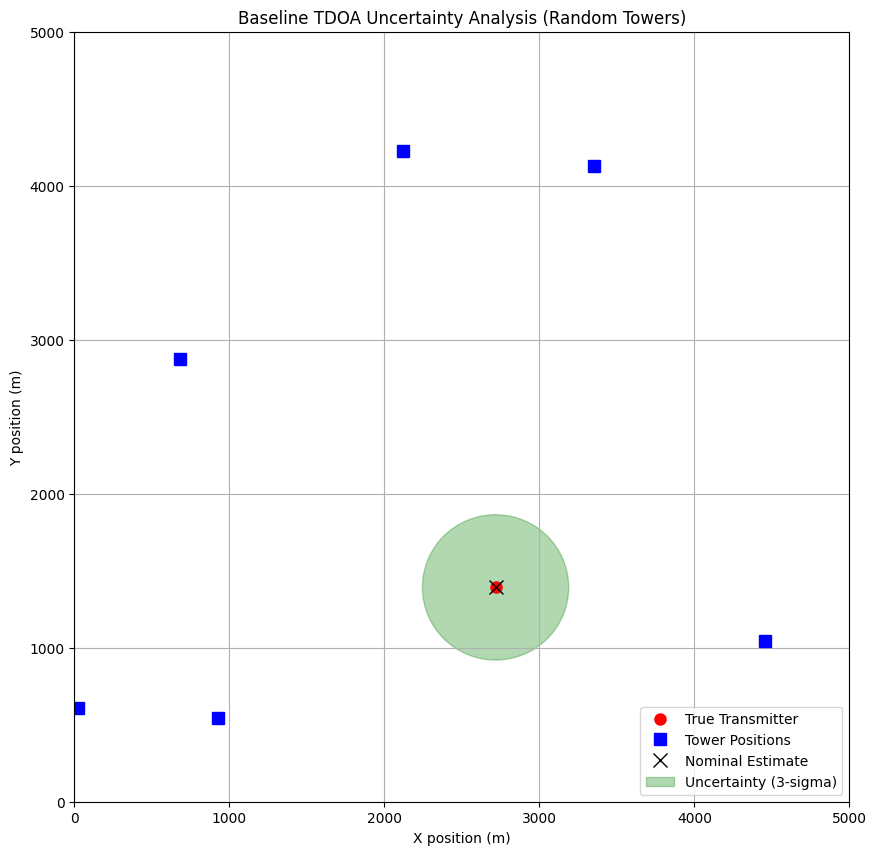

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(true_tx[0], true_tx[1], "ro", markersize=8, label="True Transmitter")
ax.plot(
    towers_true[:, 0], towers_true[:, 1], "bs", markersize=8, label="Tower Positions"
)
ax.plot(est_nom[0], est_nom[1], "kx", markersize=10, label="Nominal Estimate")
uncertainty_circle = Circle(
    (est_nom[0], est_nom[1]),
    uncertainty_radius_total,
    color="green",
    alpha=0.3,
    label="Uncertainty ({}-sigma)".format(conf_mult),
)
ax.add_patch(uncertainty_circle)
ax.set_xlabel("X position (m)")
ax.set_ylabel("Y position (m)")
ax.set_title("Baseline TDOA Uncertainty Analysis (Random Towers)")
ax.legend(loc="lower right")
ax.grid(True)
ax.set_xlim(0, region_size)
ax.set_ylim(0, region_size)
plt.show()

## Brute Force Simulation (Random Towers)

Next, we run a brute-force simulation over many random seeds where both the transmitter and tower locations
are generated randomly. For each seed, we:

1. Compute the nominal TDOA solution using error-free times-of-arrival.
2. Compute the localization error (distance between true and estimated transmitter).
3. Compute the uncertainty (scaled via error propagation).

Finally, we calculate overall statistics (mean and standard deviation) and visualize the distribution.


In [29]:
errors_list = []
scaled_radii_list = []

for seed in range(n_seeds):
    np.random.seed(seed)
    # Generate random transmitter and tower locations
    true_tx_local = np.random.uniform(0, region_size, 2)
    towers_true_local = np.random.uniform(0, region_size, (n_towers, 2))

    # Compute distances and ideal times-of-arrival
    dists_nom_local = np.linalg.norm(towers_true_local - true_tx_local, axis=1)
    times_nom_local = dists_nom_local / c
    time_diffs_nom_local = times_nom_local - times_nom_local[0]

    # Solve for transmitter position
    initial_guess_local = towers_true_local[0]
    sol_nom_local = least_squares(
        tdoa_residuals,
        initial_guess_local,
        args=(towers_true_local, time_diffs_nom_local, c),
        bounds=([0, 0], [region_size, region_size]),
    )
    est_nom_local = sol_nom_local.x
    error_local = np.linalg.norm(est_nom_local - true_tx_local)
    errors_list.append(error_local)

    # Compute uncertainty via Jacobian
    J_local = sol_nom_local.jac
    sigma_eff_local = np.sqrt((c * time_error) ** 2 + gps_error**2)
    cov_local = sigma_eff_local**2 * np.linalg.inv(J_local.T @ J_local)
    r_1sigma_local = np.sqrt((cov_local[0, 0] + cov_local[1, 1]) / 2)
    scaled_radius_local = conf_mult * r_1sigma_local
    scaled_radii_list.append(scaled_radius_local)

# Compute overall statistics
mean_error = np.mean(errors_list)
std_error = np.std(errors_list)
mean_scaled_radius = np.mean(scaled_radii_list)
std_scaled_radius = np.std(scaled_radii_list)

print("Brute Force Statistics over {} seeds:".format(n_seeds))
print(
    "Average localization error: {:.2f} m (std: {:.2f} m)".format(mean_error, std_error)
)
print(
    "Average scaled uncertainty radius ({}-sigma): {:.2f} m (std: {:.2f} m)".format(
        conf_mult, mean_scaled_radius, std_scaled_radius
    )
)

Brute Force Statistics over 1000 seeds:
Average localization error: 59.77 m (std: 465.38 m)
Average scaled uncertainty radius (3-sigma): 1761.70 m (std: 2133.72 m)


## Optimization 1: Deterministic Tower Placement by Maximizing Separation

As an alternative to random tower placement, we can optimize the tower positions to maximize their separation.

We define an objective function that computes the minimum pairwise distance among towers. By minimizing the negative of that value, we maximize the minimum separation.

The optimized tower positions are then used (fixed) for subsequent TDOA simulations.

In [30]:
def max_min_distance_objective(tower_positions, n_towers):
    """
    Objective function to maximize the minimum pairwise distance among towers.

    Parameters:
      tower_positions : array_like
          Flattened array of length 2*n_towers representing tower positions.
      n_towers : int
          Number of towers.

    Returns:
      Negative of the minimum pairwise distance (so that minimization maximizes the separation).
    """
    towers = tower_positions.reshape((n_towers, 2))
    min_dist = np.inf
    for i in range(n_towers):
        for j in range(i + 1, n_towers):
            d = np.linalg.norm(towers[i] - towers[j])
            if d < min_dist:
                min_dist = d
    return -min_dist

### Optimize Tower Positions

We use differential evolution (a global optimizer) to determine the optimal tower positions in the region
that maximize the minimum pairwise distance.

In [31]:
bounds = [(0, region_size)] * (2 * n_towers)
result = differential_evolution(
    max_min_distance_objective,
    bounds,
    args=(n_towers,),
    maxiter=1000,
    popsize=15,
    disp=True,
)
optimal_tower_positions_opt = result.x.reshape((n_towers, 2))
optimal_min_distance = -result.fun

print("Optimized Tower Positions (Maximizing Separation):")
print(optimal_tower_positions_opt)
print("Maximum minimum pairwise distance: {:.2f} m".format(optimal_min_distance))

differential_evolution step 1: f(x)= -1489.6821826562732
differential_evolution step 2: f(x)= -1489.6821826562732
differential_evolution step 3: f(x)= -1489.6821826562732
differential_evolution step 4: f(x)= -1684.4045205994037
differential_evolution step 5: f(x)= -1684.4045205994037
differential_evolution step 6: f(x)= -1700.9981464207117
differential_evolution step 7: f(x)= -1824.4886945599687
differential_evolution step 8: f(x)= -1824.4886945599687
differential_evolution step 9: f(x)= -1824.4886945599687
differential_evolution step 10: f(x)= -1903.1035348507558
differential_evolution step 11: f(x)= -1903.1035348507558
differential_evolution step 12: f(x)= -1903.1035348507558
differential_evolution step 13: f(x)= -1903.1035348507558
differential_evolution step 14: f(x)= -1903.1035348507558
differential_evolution step 15: f(x)= -1903.1035348507558
differential_evolution step 16: f(x)= -1903.1035348507558
differential_evolution step 17: f(x)= -1903.1035348507558
differential_evolution 

### Visualization of the Optimized Tower Placement

The plot below shows the optimized tower positions within the region.

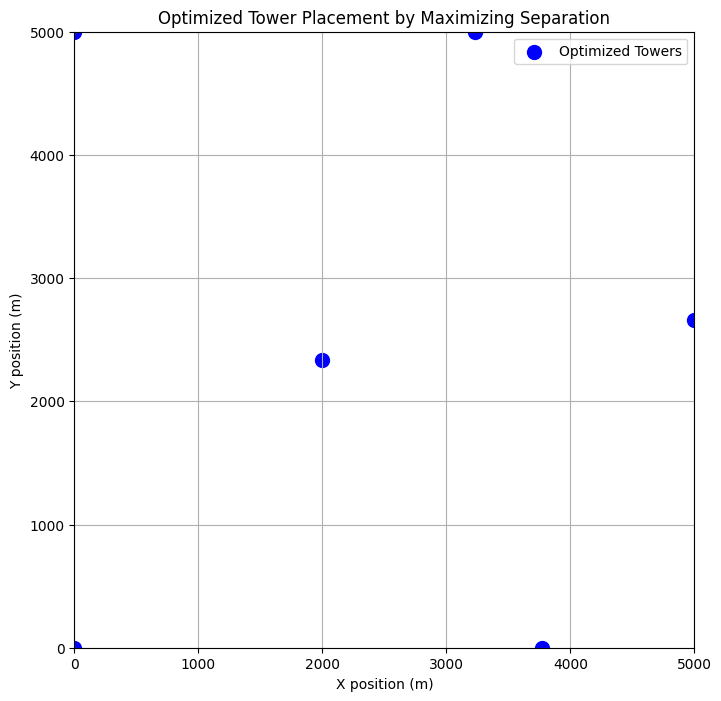

In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(
    optimal_tower_positions_opt[:, 0],
    optimal_tower_positions_opt[:, 1],
    color="blue",
    marker="o",
    s=100,
    label="Optimized Towers",
)
plt.xlim(0, region_size)
plt.ylim(0, region_size)
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Optimized Tower Placement by Maximizing Separation")
plt.legend()
plt.grid(True)
plt.show()

## Single Simulation with Optimized Towers

Using the optimized tower positions (fixed for the region), we perform a single TDOA simulation. A random transmitter is generated, the nominal TDOA solution is computed, and its uncertainty is estimated.


Optimized Towers - Single Simulation:
True Transmitter Location: [2581.99313851 2853.33793434]
Nominal Estimated Location: [2581.99313851 2853.33793434]
Localization Error: 0.00 m
Scaled Uncertainty Radius (3-sigma): 415.04 m


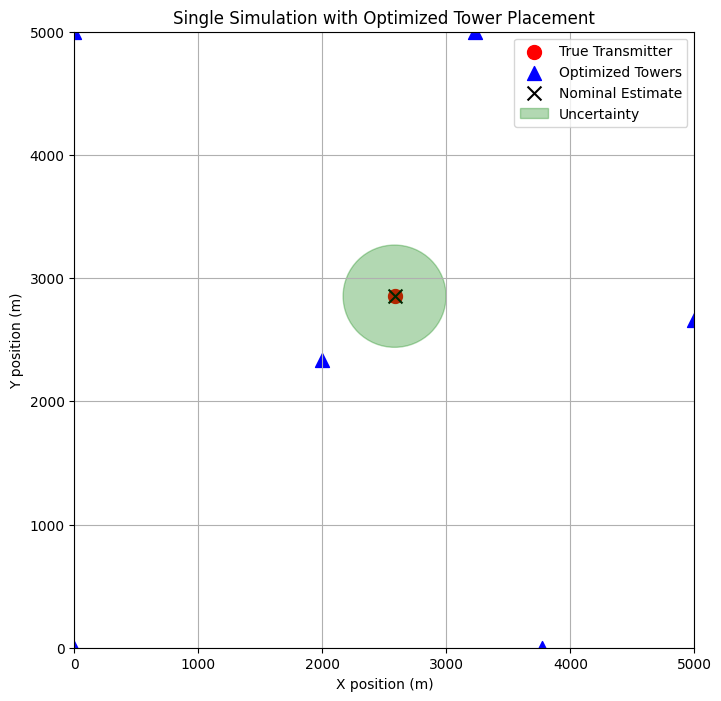

In [33]:
# For reproducibility, use a fixed seed
np.random.seed(101)
true_tx_opt = np.random.uniform(0, region_size, 2)

# Compute distances and ideal times-of-arrival for optimized towers
dists_nom_opt = np.linalg.norm(optimal_tower_positions_opt - true_tx_opt, axis=1)
times_nom_opt = dists_nom_opt / c
time_diffs_nom_opt = times_nom_opt - times_nom_opt[0]

initial_guess_opt = optimal_tower_positions_opt[0]
sol_nom_opt = least_squares(
    tdoa_residuals,
    initial_guess_opt,
    args=(optimal_tower_positions_opt, time_diffs_nom_opt, c),
    bounds=([0, 0], [region_size, region_size]),
)
est_nom_opt = sol_nom_opt.x

# Compute uncertainty via Jacobian
J_opt = sol_nom_opt.jac
sigma_eff_opt = np.sqrt((c * time_error) ** 2 + gps_error**2)
cov_opt = sigma_eff_opt**2 * np.linalg.inv(J_opt.T @ J_opt)
r_1sigma_opt = np.sqrt((cov_opt[0, 0] + cov_opt[1, 1]) / 2)
scaled_radius_opt = conf_mult * r_1sigma_opt

loc_error_opt = np.linalg.norm(est_nom_opt - true_tx_opt)
print("Optimized Towers - Single Simulation:")
print("True Transmitter Location:", true_tx_opt)
print("Nominal Estimated Location:", est_nom_opt)
print("Localization Error: {:.2f} m".format(loc_error_opt))
print(
    "Scaled Uncertainty Radius ({}-sigma): {:.2f} m".format(
        conf_mult, scaled_radius_opt
    )
)

# Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(
    true_tx_opt[0], true_tx_opt[1], color="red", s=100, label="True Transmitter"
)
plt.scatter(
    optimal_tower_positions_opt[:, 0],
    optimal_tower_positions_opt[:, 1],
    color="blue",
    marker="^",
    s=100,
    label="Optimized Towers",
)
plt.scatter(
    est_nom_opt[0],
    est_nom_opt[1],
    color="black",
    marker="x",
    s=100,
    label="Nominal Estimate",
)
uncertainty_circle_opt = Circle(
    (est_nom_opt[0], est_nom_opt[1]),
    scaled_radius_opt,
    color="green",
    alpha=0.3,
    label="Uncertainty",
)
plt.gca().add_patch(uncertainty_circle_opt)
plt.xlim(0, region_size)
plt.ylim(0, region_size)
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Single Simulation with Optimized Tower Placement")
plt.legend()
plt.grid(True)
plt.show()

## Brute Force Simulation with Optimized Towers
Finally, we run a brute-force simulation (over many random seeds) using the fixed optimized tower positions.
For each seed, a random transmitter is generated, the nominal TDOA solution is computed, and we record:

- Localization error,
- And the scaled uncertainty radius (via error propagation).

Overall statistics are then computed and printed.


In [34]:
errors_list_opt = []
scaled_radii_list_opt = []

for seed in range(n_seeds):
    np.random.seed(seed)
    true_tx_local = np.random.uniform(0, region_size, 2)

    dists_nom_local = np.linalg.norm(
        optimal_tower_positions_opt - true_tx_local, axis=1
    )
    times_nom_local = dists_nom_local / c
    time_diffs_nom_local = times_nom_local - times_nom_local[0]

    initial_guess_local = optimal_tower_positions_opt[0]
    sol_nom_local = least_squares(
        tdoa_residuals,
        initial_guess_local,
        args=(optimal_tower_positions_opt, time_diffs_nom_local, c),
        bounds=([0, 0], [region_size, region_size]),
    )
    est_nom_local = sol_nom_local.x
    error_local = np.linalg.norm(est_nom_local - true_tx_local)
    errors_list_opt.append(error_local)

    J_local = sol_nom_local.jac
    sigma_eff_local = np.sqrt((c * time_error) ** 2 + gps_error**2)
    cov_local = sigma_eff_local**2 * np.linalg.inv(J_local.T @ J_local)
    r_1sigma_local = np.sqrt((cov_local[0, 0] + cov_local[1, 1]) / 2)
    scaled_radius_local = conf_mult * r_1sigma_local
    scaled_radii_list_opt.append(scaled_radius_local)

mean_error_opt = np.mean(errors_list_opt)
std_error_opt = np.std(errors_list_opt)
mean_scaled_radius_opt = np.mean(scaled_radii_list_opt)
std_scaled_radius_opt = np.std(scaled_radii_list_opt)

print("Brute Force Statistics with Optimized Towers over {} seeds:".format(n_seeds))
print(
    "Average Localization Error: {:.2f} m (std: {:.2f} m)".format(
        mean_error_opt, std_error_opt
    )
)
print(
    "Average Scaled Uncertainty Radius ({}-sigma): {:.2f} m (std: {:.2f} m)".format(
        conf_mult, mean_scaled_radius_opt, std_scaled_radius_opt
    )
)

Brute Force Statistics with Optimized Towers over 1000 seeds:
Average Localization Error: 0.00 m (std: 0.00 m)
Average Scaled Uncertainty Radius (3-sigma): 550.41 m (std: 179.68 m)


## Sensitivity Analysis: Impact of GPS and Time Errors

In this section, we study how different levels of GPS error and time error affect the localization performance. We use the fixed optimized tower positions and, for each combination of error parameters, run a brute-force simulation (using a reduced number of seeds for speed) to compute the average localization error and the average scaled uncertainty radius.

The results are displayed as heatmaps.

In [ ]:
# Define wider/finer ranges for GPS and time errors:
gps_error_range = np.linspace(0.5, 20, 30)  # 30 values from 0.5 m to 20 m
time_error_range = np.linspace(1e-8, 1e-5, 30)  # 30 values from 1e-8 s to 1e-5 s

# Use a reduced number of seeds for sensitivity analysis (for speed)
n_seeds_sensitivity = 200

# Matrices to store the results
mean_loc_error_matrix = np.zeros((len(gps_error_range), len(time_error_range)))
mean_uncertainty_matrix = np.zeros((len(gps_error_range), len(time_error_range)))

# Loop over all combinations of error parameters
for i, gps_err in enumerate(gps_error_range):
    for j, t_err in enumerate(time_error_range):
        errors_list_temp = []
        scaled_radii_list_temp = []
        for seed in range(n_seeds_sensitivity):
            np.random.seed(seed)
            # Generate a true transmitter location (random in the region)
            true_tx_local = np.random.uniform(0, region_size, 2)
            # Simulate noisy tower positions from fixed optimized towers
            towers_measured = optimal_tower_positions_opt + np.random.normal(
                0, gps_err, optimal_tower_positions_opt.shape
            )

            # Compute distances from the true transmitter to the (noisy) towers
            dists_local = np.linalg.norm(towers_measured - true_tx_local, axis=1)
            # Compute ideal times-of-arrival from these distances
            times_true = dists_local / c
            # Add time noise to simulate measurement error
            times_measured = times_true + np.random.normal(0, t_err, times_true.shape)
            # Use the first tower as the reference
            time_diffs_measured = times_measured - times_measured[0]

            # Solve for the transmitter position using the noisy towers and time differences
            initial_guess_local = np.clip(towers_measured[0], 0, region_size)
            sol_local = least_squares(
                tdoa_residuals,
                initial_guess_local,
                args=(towers_measured, time_diffs_measured, c),
                bounds=([0, 0], [region_size, region_size]),
            )
            est_local = sol_local.x
            error_local = np.linalg.norm(est_local - true_tx_local)
            errors_list_temp.append(error_local)

            # Compute uncertainty via error propagation
            sigma_eff_local = np.sqrt((c * t_err) ** 2 + gps_err**2)
            J_local = sol_local.jac
            # Invert the (J^T J) matrix; if nearly singular, skip this iteration
            try:
                cov_local = sigma_eff_local**2 * np.linalg.inv(J_local.T @ J_local)
                r_1sigma_local = np.sqrt((cov_local[0, 0] + cov_local[1, 1]) / 2)
            except np.linalg.LinAlgError:
                r_1sigma_local = np.nan
            scaled_radius_local = conf_mult * r_1sigma_local
            scaled_radii_list_temp.append(scaled_radius_local)

        # Average over the seeds (ignoring any NaNs)
        mean_loc_error_matrix[i, j] = np.nanmean(errors_list_temp)
        mean_uncertainty_matrix[i, j] = np.nanmean(scaled_radii_list_temp)

ValueError: Initial guess is outside of provided bounds

### Plotting Sensitivity Results

The following heatmaps show the average localization error and the average scaled uncertainty radius as functions of the GPS error (in meters) and time error (in seconds).


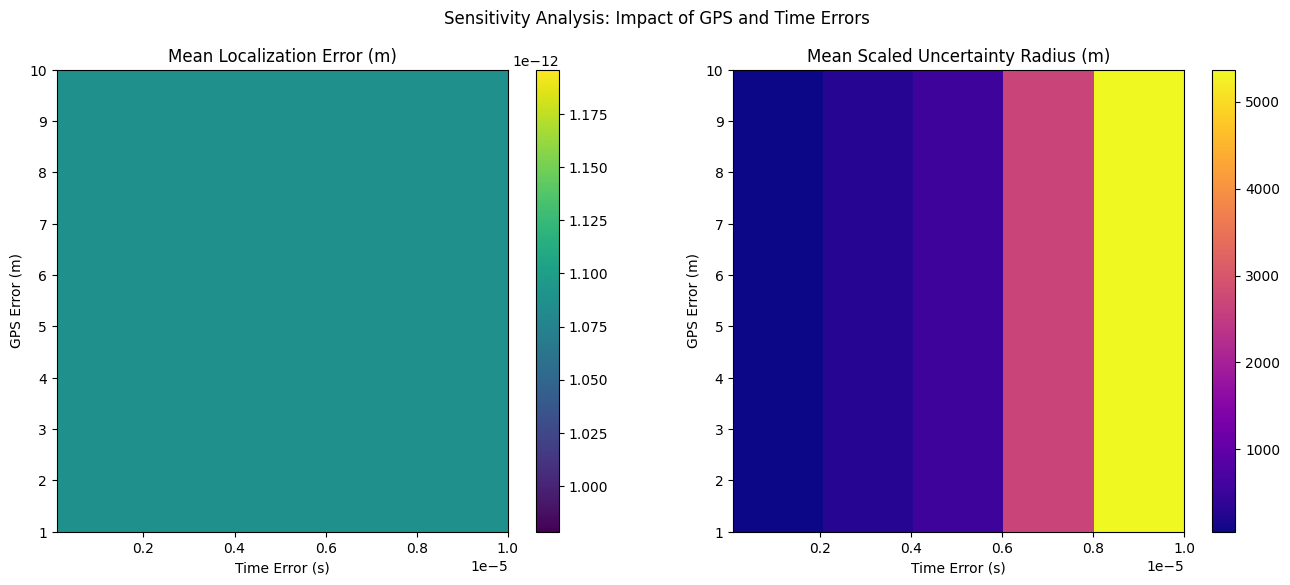

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for Mean Localization Error
im1 = axs[0].imshow(
    mean_loc_error_matrix,
    origin="lower",
    aspect="auto",
    extent=[
        time_error_range[0],
        time_error_range[-1],
        gps_error_range[0],
        gps_error_range[-1],
    ],
    cmap="viridis",
)
axs[0].set_xlabel("Time Error (s)")
axs[0].set_ylabel("GPS Error (m)")
axs[0].set_title("Mean Localization Error (m)")
fig.colorbar(im1, ax=axs[0])

# Heatmap for Mean Scaled Uncertainty Radius
im2 = axs[1].imshow(
    mean_uncertainty_matrix,
    origin="lower",
    aspect="auto",
    extent=[
        time_error_range[0],
        time_error_range[-1],
        gps_error_range[0],
        gps_error_range[-1],
    ],
    cmap="plasma",
)
axs[1].set_xlabel("Time Error (s)")
axs[1].set_ylabel("GPS Error (m)")
axs[1].set_title("Mean Scaled Uncertainty Radius (m)")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("Sensitivity Analysis: Impact of GPS and Time Errors (Noisy Measurements)")
plt.show()